Tarefas 
- entender porque o shap do tradicional gbr nao esta compativel com o artigo. sera que foi usado set de treino? 
- terminar de importar os codigos de injecao de ruidos e analises morfologicas
- Consolidar todas as "observacao" para melhor entendimento
- Em relação ao Shap values entender as diferencas nos tipos de graficos



# 0. Imports and global configuration


In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import cross_val_predict, KFold, train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Data loading and description 

## Read data

In [4]:
# Load Dataset (replace 'file_path' with your file location in Colab)
file_path = './content/dados_jamovi.xlsx'  # Upload your dataset to Colab
data = pd.read_excel(file_path)


## Data Description

In [5]:
data.head()

,Dmax (mean) [µm],Dmed (mean) [µm],Dmin (mean) [µm],Area (mean) [µm²],Velocity (mean) [µm/s],Distance (sum) [µm],Rel.Time (num) [s],Area (polygon) (mean) [µm²],Area/Box (mean) [µm²],Axis (major) (mean) [µm],...,Perim. (convex) (mean) [µm],Perim. (ellipse) (mean) [µm],Perim. (ratio) (mean) [µm],Perimeter2 (mean) [µm],Perimeter3 (mean) [µm],Radius (max) (mean) [µm],Radius (min) (mean) [µm],Roundness (mean),Size (length) (mean) [µm],Size (width) (mean) [µm]
0,2278.275745,1551.198298,711.606809,1.612164e+06,1399.779783,6438.99,47,1466525.53,0.46,2284.51,...,5746.35,5338.09,0.82,7615.24,7006.98,1329.19,267.71,2.67,2360.02,1219.27
1,3442.800833,2611.194583,1959.983750,5.709536e+06,2415.071739,5554.67,24,5488243.60,0.73,3343.78,...,9110.69,8811.35,0.90,10708.58,10125.68,1770.54,859.83,1.49,3405.16,2470.43
2,2372.206296,1943.840370,1434.028889,3.149271e+06,2265.156923,5889.41,27,2978574.57,0.61,2279.25,...,7027.62,6492.88,0.81,9172.29,8647.90,1434.45,511.19,2.01,2495.45,2040.84
3,1921.425405,1496.906486,1080.961892,1.835665e+06,1804.333056,6495.60,37,1711958.32,0.63,1838.61,...,5162.67,4959.59,0.84,6476.37,6131.23,1031.68,466.54,1.75,1889.67,1450.77
4,1987.391429,1533.741429,934.360000,1.807783e+06,1861.068333,1116.64,7,1682195.05,0.59,2114.39,...,5396.27,5191.92,0.90,6369.07,5980.95,1079.78,418.74,1.69,2009.11,1196.00


In [6]:
data.columns # acrescentar a descricao das colunas e definir a variavel target

Index(['Dmax (mean) [µm]', 'Dmed (mean) [µm]', 'Dmin (mean) [µm]',
       'Area (mean) [µm²]', 'Velocity (mean) [µm/s]', 'Distance (sum) [µm]',
       'Rel.Time (num) [s]', 'Area (polygon) (mean) [µm²]',
       'Area/Box (mean) [µm²]', 'Axis (major) (mean) [µm]',
       'Axis (minor) (mean) [µm]', 'Box Height (mean) [µm]',
       'Box Width (mean) [µm]', 'Box X/Y (mean) [µm]', 'Clumpiness (mean)',
       'Cluster (mean)', 'Count (adjusted) (mean)',
       'Den./Inten. (std.dev.) (mean)', 'Den./Inten. (mean)',
       'Feret (max) (mean)', 'Feret (mean) (mean)', 'Feret (min) (mean)',
       'Fractal Dim. (mean)', 'Heterogeneity (mean)', 'Hole Area (mean) [µm²]',
       'Hole Ratio (mean)', 'Holes (mean)', 'Margination (mean)',
       'Perim. (convex) (mean) [µm]', 'Perim. (ellipse) (mean) [µm]',
       'Perim. (ratio) (mean) [µm]', 'Perimeter2 (mean) [µm]',
       'Perimeter3 (mean) [µm]', 'Radius (max) (mean) [µm]',
       'Radius (min) (mean) [µm]', 'Roundness (mean)',
       'Size (le

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 916 entries, 0 to 915
Data columns (total 38 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Dmax (mean) [µm]               916 non-null    float64
 1   Dmed (mean) [µm]               916 non-null    float64
 2   Dmin (mean) [µm]               883 non-null    float64
 3   Area (mean) [µm²]              916 non-null    float64
 4   Velocity (mean) [µm/s]         916 non-null    float64
 5   Distance (sum) [µm]            916 non-null    float64
 6   Rel.Time (num) [s]             916 non-null    int64  
 7   Area (polygon) (mean) [µm²]    916 non-null    float64
 8   Area/Box (mean) [µm²]          916 non-null    float64
 9   Axis (major) (mean) [µm]       916 non-null    float64
 10  Axis (minor) (mean) [µm]       916 non-null    float64
 11  Box Height (mean) [µm]         916 non-null    float64
 12  Box Width (mean) [µm]          916 non-null    flo

In [8]:
data.select_dtypes(include=[np.number])

,Dmax (mean) [µm],Dmed (mean) [µm],Dmin (mean) [µm],Area (mean) [µm²],Velocity (mean) [µm/s],Distance (sum) [µm],Rel.Time (num) [s],Area (polygon) (mean) [µm²],Area/Box (mean) [µm²],Axis (major) (mean) [µm],...,Perim. (convex) (mean) [µm],Perim. (ellipse) (mean) [µm],Perim. (ratio) (mean) [µm],Perimeter2 (mean) [µm],Perimeter3 (mean) [µm],Radius (max) (mean) [µm],Radius (min) (mean) [µm],Roundness (mean),Size (length) (mean) [µm],Size (width) (mean) [µm]
0,2278.275745,1551.198298,711.606809,1.612164e+06,1399.779783,6438.99,47,1466525.53,0.46,2284.51,...,5746.35,5338.09,0.82,7615.24,7006.98,1329.19,267.71,2.67,2360.02,1219.27
1,3442.800833,2611.194583,1959.983750,5.709536e+06,2415.071739,5554.67,24,5488243.60,0.73,3343.78,...,9110.69,8811.35,0.90,10708.58,10125.68,1770.54,859.83,1.49,3405.16,2470.43
2,2372.206296,1943.840370,1434.028889,3.149271e+06,2265.156923,5889.41,27,2978574.57,0.61,2279.25,...,7027.62,6492.88,0.81,9172.29,8647.90,1434.45,511.19,2.01,2495.45,2040.84
3,1921.425405,1496.906486,1080.961892,1.835665e+06,1804.333056,6495.60,37,1711958.32,0.63,1838.61,...,5162.67,4959.59,0.84,6476.37,6131.23,1031.68,466.54,1.75,1889.67,1450.77
4,1987.391429,1533.741429,934.360000,1.807783e+06,1861.068333,1116.64,7,1682195.05,0.59,2114.39,...,5396.27,5191.92,0.90,6369.07,5980.95,1079.78,418.74,1.69,2009.11,1196.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
911,3136.153200,2408.649600,1890.947000,4.812445e+06,2872.106122,14073.32,50,4617799.53,0.63,2953.81,...,8412.13,8012.02,0.95,9366.66,8880.15,1652.12,837.00,1.36,2990.50,2219.97
912,2812.451333,2076.334800,1401.347973,3.474430e+06,1696.029730,12550.62,75,3275391.71,0.54,2682.56,...,7902.23,7138.59,0.81,10699.62,9812.46,1508.24,604.67,2.37,2809.86,2132.47
913,2799.677391,1894.347536,813.373529,2.391134e+06,1725.002941,11730.02,69,2226172.89,0.46,2987.35,...,6990.49,6801.41,0.92,8057.59,7628.13,1618.95,180.22,2.12,2959.49,1275.28
914,2312.610000,1682.490200,794.600408,2.213474e+06,1702.832653,8343.88,50,2042021.79,0.60,2319.41,...,6160.02,5803.88,0.77,8521.31,8015.60,1237.14,213.92,2.52,2295.89,1519.96


# 2. Declare predictor and target variable

In [9]:
target_column = 'Velocity (mean) [µm/s]'
features_columns = [col for col in data.columns if col != target_column]

In [10]:
X = data[features_columns]
y = data[target_column]

In [11]:
mask = X.notna().all(axis=1) & y.notna()

X = X.loc[mask]
y = y.loc[mask]


# 3. Split train and test set

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state = 42 
)

# 3. Modeling Experiments

##### Observacao 

- foi introduzido um hiperparametro (max_depth) no treinamento do modelo

## Experiment A - Traditional Gradient Boosting Regressor 


### Train and predict

In [13]:

# Define the Gradient Boosting Regressor
traditional_gbr_model = GradientBoostingRegressor(
    n_estimators=200, 
    learning_rate=0.05, 
    max_depth= 3, # esse hiperparametro nao aparecia no paper original 
    random_state=42
    )


In [14]:
# Fit the model
traditional_gbr_model.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft

In [15]:
# Make prediction
y_pred = traditional_gbr_model.predict(X_test)

### Calculate residuals 

In [16]:
trad_gbr_residuals = y_test - y_pred

### Save results for evaluation analysis

In [17]:
df_eval_a = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_pred,
    "residuals": trad_gbr_residuals,
    "experiment": "Tradicional GBR"
})


## Experiment B - Physics-based feature engineering Gradient Boosting Regressor (PFE - GBR)


- **Reynolds number (Re):** captures flow regime effects
- **Drag coefficient (Cd):** accounts for non-linear drag behavior
- **Drag force (Fd):** expresses momentum exchange

A characteristic velocity is used in the computation of these quantities and is obtained from experimental measurements.

### Feature Engineering

#### Phisical features

##### Observacao
- No codigo original, para o calculo de Re é utilizado o raio, enquanto aqui foi utilizado o diametro equivalente por área projetada
- Esta havendo leakage de informacao: isso porque para o calculo de Reynolds utiliza-se a velocidade caracteristica que é a resposta que o sistema procura
    - Utilizar pipeline nao resolverá: a velocidade caracteristica ainda será vazada para dentro do modelo 
    - Propostas:
        - testar a efetividade do modelo sem a utilização de Reynolds como variavel preditora
        - testar a utilização de Stokes como substituto para "velocidade caracteristica" - assim nao haverá leakage

In [18]:
# Copy data
data_run2 = data.copy()

In [19]:
# Versao 2 da Feature Engineering
# Principal diferença dessa versao da feature engineering é a utilizacao do d (em lugar do 'Radius (max) (mean) [µm]') para o calculo de Re

rho_f = 1000.0
mu = 0.001
g = 9.81  # Gravitational acceleration (m/s²)
rho_p = 2600  # Particle density (kg/m³)

A = data_run2["Area (mean) [µm²]"] * 1e-12      # área projetada (m²)
r = data_run2["Radius (max) (mean) [µm]"] * 1e-6    # raio maximo (m)
v = data_run2[target_column] * 1e-6        # velocidade medida (m/s)

d = 2.0 * np.sqrt(A / np.pi) # # Diâmetro equivalente por área projetada: d = 2*sqrt(A/pi)
Re = (rho_f * v * d) / mu # no codigo original em vez de "d" usamos simplesmente o raio 
Re = Re.replace([np.inf, -np.inf], np.nan)
Re = Re.where(Re > 0, np.nan)

# Re = (
#     Re
#     .where(Re > 0) # remove valores não físicos
#     .replace([np.inf, -np.inf], np.nan) # remove infinitos
# )
# “Non-physical Reynolds number values (Re ≤ 0) and infinite values arising from numerical instabilities were discarded and treated as missing data prior to model training.”
# Re = 0 representa velocidade nula o que nao importa no processo
# Re < 0 nao faz sentido, dado que velocidade e as outras variaveis nunca serao menor que 0

Cd = 24.0 / Re
Fd = 0.5 * rho_f * Cd * A * (v ** 2)
r2 = r ** 2
Stokes = (2 / 9) * ((rho_p - rho_f) * g * r2 / mu)

data_run2["PFE_Re"] = Re
data_run2["PFE_Cd"] = Cd
data_run2["PFE_Fd"] = Fd
data_run2["PFE_r2"] = r2


# physics_features = ['PFE_r2', 'PFE_Re', 'PFE_Cd', 'PFE_Fd']
physics_features = ['PFE_Re', 'PFE_Cd',  'PFE_Fd', 'PFE_r2']


In [20]:
X_train_pfe = pd.concat([X_train, data_run2.loc[X_train.index,physics_features]], axis=1)
X_test_pfe = pd.concat([X_test, data_run2.loc[X_test.index,physics_features]], axis=1)

In [21]:

# # Impute Missing Values
# imputer = SimpleImputer(strategy='mean')
# X_pfe_imputed = imputer.fit_transform(X_pfe)


### Training model

In [22]:

# Define the Gradient Boosting Regressor
pfe_gbr_model = GradientBoostingRegressor(
    n_estimators=200, 
    learning_rate=0.05, 
    max_depth = 3,
    random_state=42
    )


In [23]:
# Fit the model
pfe_gbr_model.fit(X_train_pfe, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft

In [24]:
# Make prediction
y_pred_pfe = pfe_gbr_model.predict(X_test_pfe)

### Calculate residuals 

In [25]:
pfe_gbr_residuals = y_test - y_pred_pfe

### Save results for evaluation analysis

In [26]:
df_eval_b = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_pred_pfe,
    "residuals": pfe_gbr_residuals, 
    "experiment": "PFE - GBR"
})

# 4. Holdout Evaluation and Error Interpretation

In [27]:
df_evaluation_analysis = pd.concat(
    [df_eval_a, df_eval_b],
    axis=0
)

In [28]:
# criar resíduos
# df_evaluation_analysis["residual"] = df_evaluation_analysis["y_true"] - df_evaluation_analysis["y_pred"]

# separar experimentos
df_evaluation_analysis_trad = df_evaluation_analysis[df_evaluation_analysis["experiment"] == "Tradicional GBR"]
df_evaluation_analysis_pfe  = df_evaluation_analysis[df_evaluation_analysis["experiment"] == "PFE - GBR"]

## Real vs Predicted Velocity


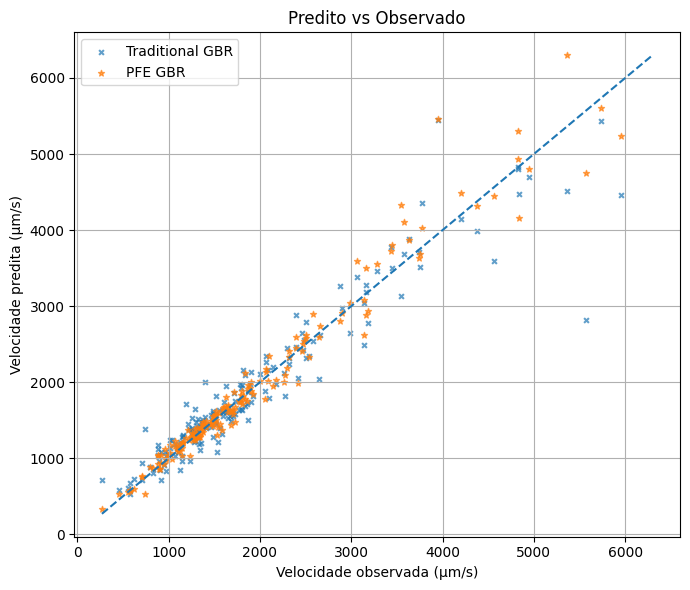

In [29]:
plt.figure(figsize=(7, 6))

# scatter tradicional
plt.scatter(
    df_evaluation_analysis_trad["y_true"],
    df_evaluation_analysis_trad["y_pred"],
    marker="x",
    alpha=0.7,
    s=12,
    label="Traditional GBR"
)

# scatter PFE
plt.scatter(
    df_evaluation_analysis_pfe["y_true"],
    df_evaluation_analysis_pfe["y_pred"],
    marker="*",
    alpha=0.7,
    s=20,
    label="PFE GBR"
)

# linha identidade
min_val = min(df_evaluation_analysis["y_true"].min(), df_evaluation_analysis["y_pred"].min())
max_val = max(df_evaluation_analysis["y_true"].max(), df_evaluation_analysis["y_pred"].max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Velocidade observada (µm/s)")
plt.ylabel("Velocidade predita (µm/s)")
plt.title("Predito vs Observado")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


##### Observacao 

1. O grafico de predito x real do artigo usa o set de treino para plotar os graficos, gerando resultados diferentes do que o codigo traz


## Error Analysis

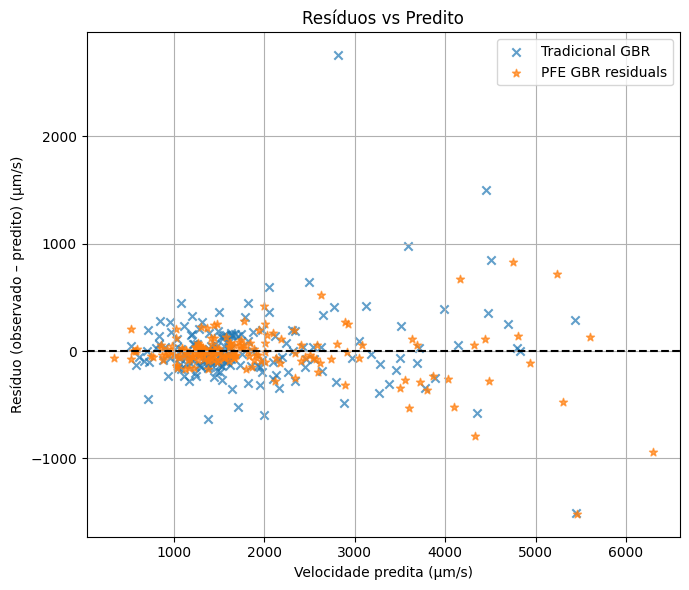

In [30]:
plt.figure(figsize=(7, 6))

# residuos Tradicional GRB
plt.scatter(
    df_evaluation_analysis_trad['y_pred'], 
    df_evaluation_analysis_trad['residuals'], 
    marker="x", 
    alpha=0.7,
    label = "Tradicional GBR"
)

# resíduos PFE
plt.scatter(
    df_evaluation_analysis_pfe['y_pred'], 
    df_evaluation_analysis_pfe['residuals'], 
    marker="*",
    alpha=0.7,
    label="PFE GBR residuals"
)

# linha zero
plt.axhline(
    0,
    linestyle="--",
    color="black"
)

plt.xlabel("Velocidade predita (µm/s)")
plt.ylabel("Resíduo (observado – predito) (µm/s)")
plt.title("Resíduos vs Predito")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [31]:
y_test.max()

np.float64(5956.226923076923)

##### Observacao

1. Enquanto Tradicional GBR prediz valores até +- 5300, o PFE faz predições que ultrapassam 6000, e justamente essas possuem os maiores residuos do sistema. Por que sera que o PFE extrapola em tanto? 
2. Vale plotar um grafico em que o eixo x são os valores reais? Assim, ficaria mais facil de entender em que intervalo em relação aos valores reais fica mais acurada a predicao

# 5. Model Interpretability - SHAP Values

## shap.TreeExplainer

### Tradicional GBR

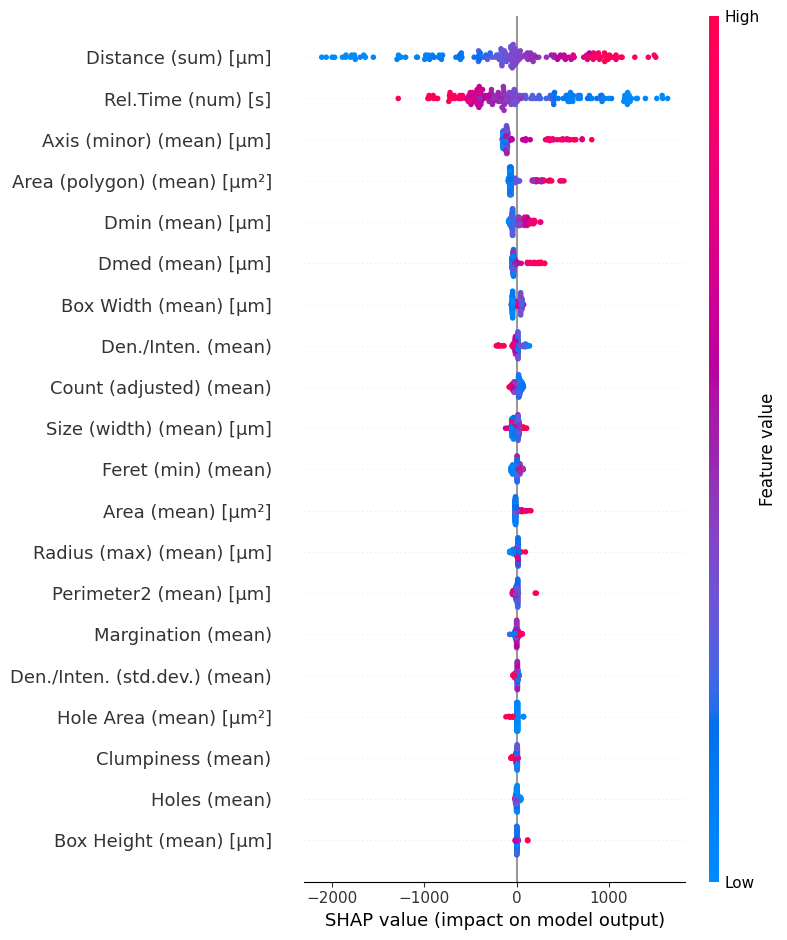

In [32]:
# Essa implementacao nao esta de acordo com o codigo. Mas é curioso entender o porque os valores se distanciaram tanto do apresentado no artigo com TreeExplainer
explainer = shap.TreeExplainer(traditional_gbr_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, show=False)


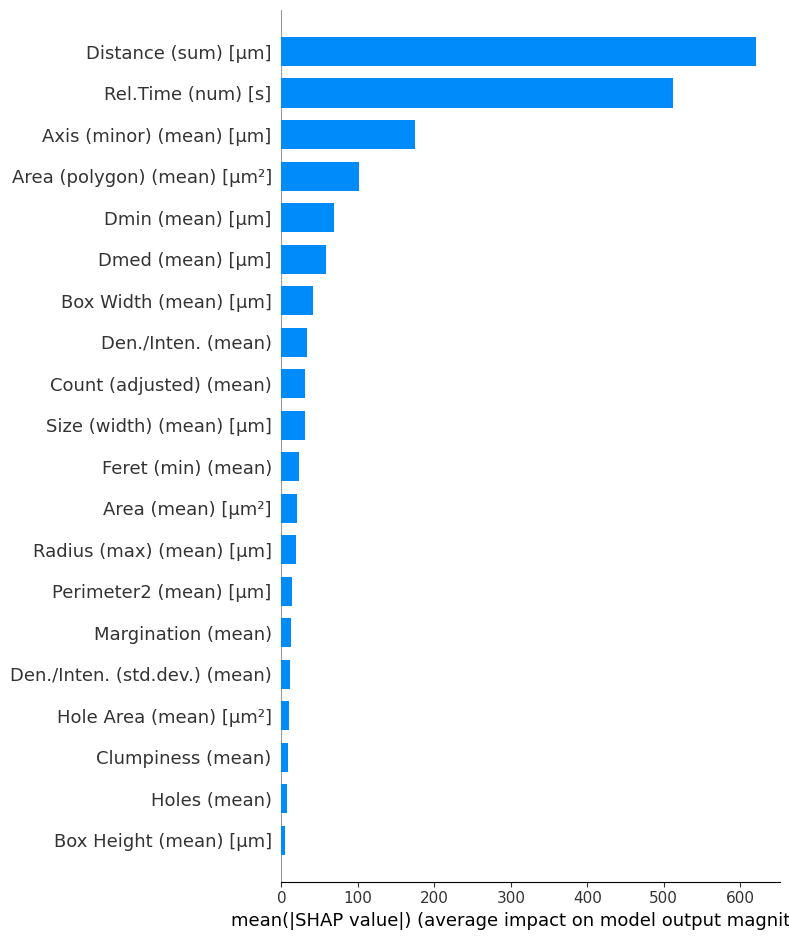

In [33]:
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.tight_layout()

### PFE - GBR

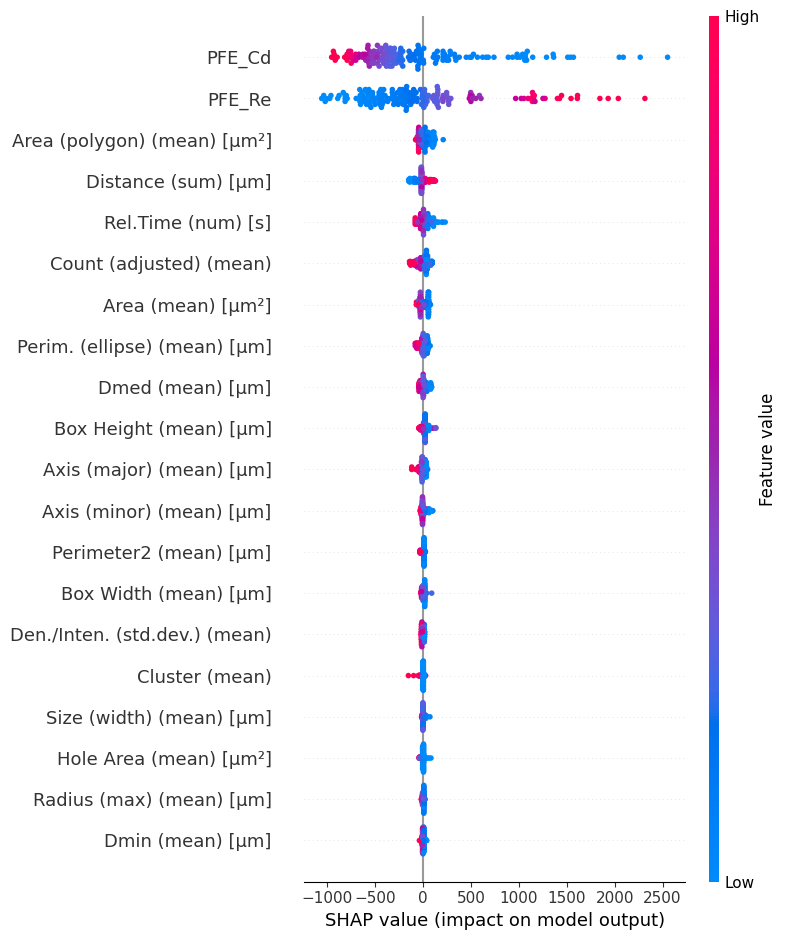

In [43]:
# PFE - GBR
explainer = shap.TreeExplainer(pfe_gbr_model)
shap_values_pfe = explainer.shap_values(X_test_pfe)

shap.summary_plot(shap_values_pfe, X_test_pfe, show=False)


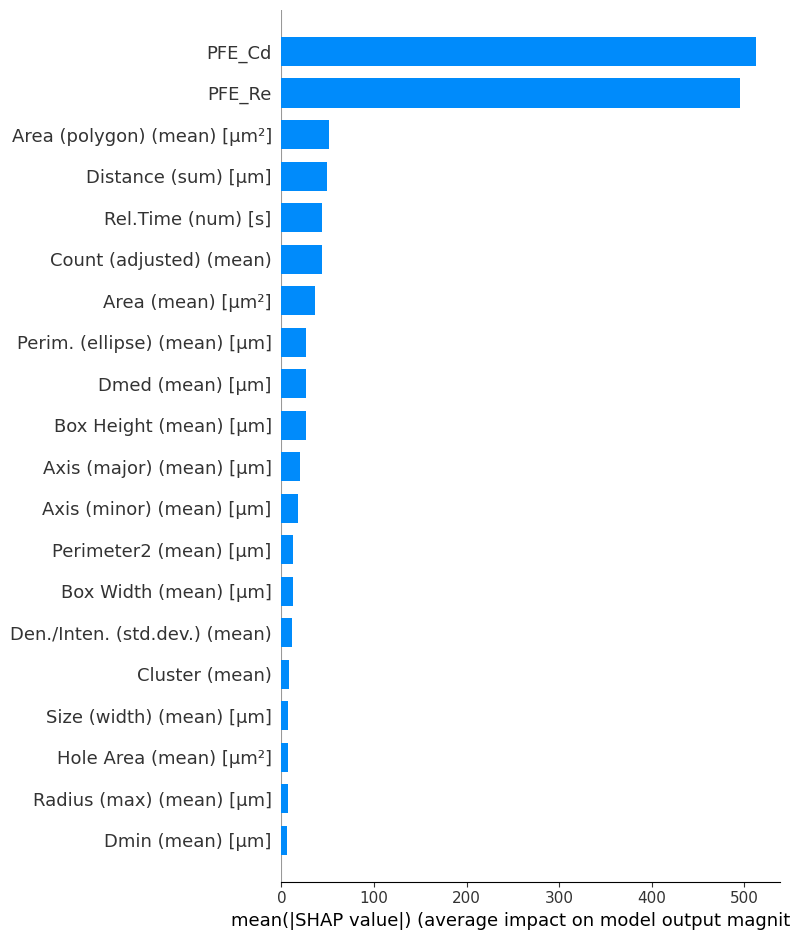

In [44]:
shap.summary_plot(shap_values_pfe, X_test_pfe, plot_type="bar", show=False)
plt.tight_layout()

## shap.Explainer

### Tradicional GBR

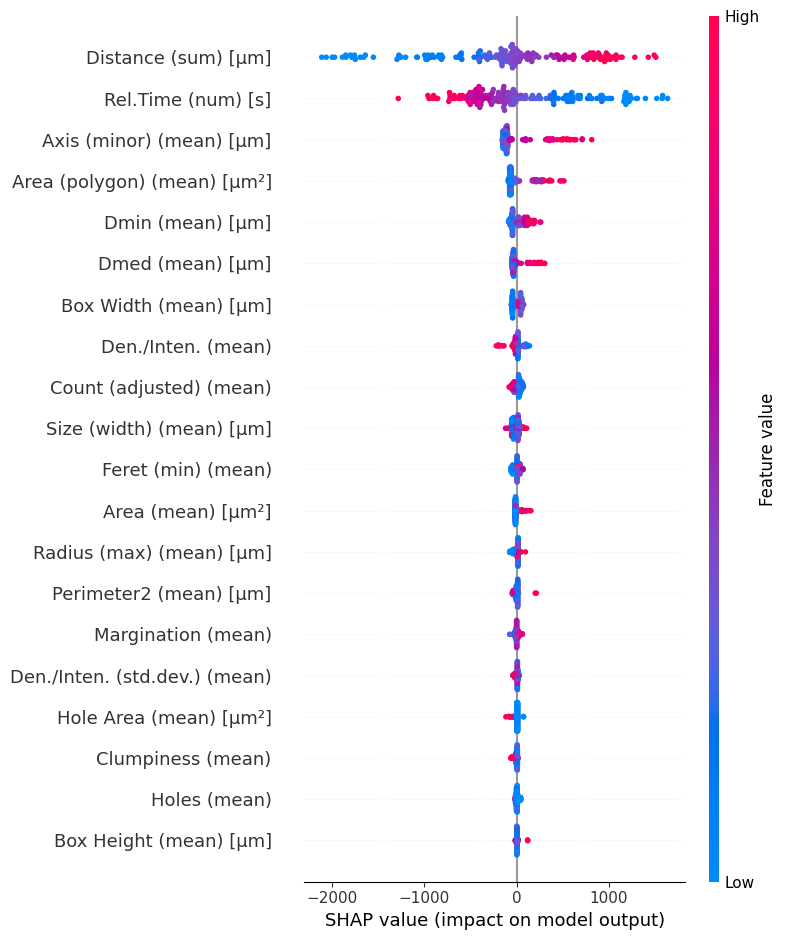

In [ ]:
# Essa implementacao nao esta de acordo com o codigo. Mas é curioso entender o porque os valores se distanciaram tanto do apresentado no artigo com TreeExplainer
explainer = shap.Explainer(traditional_gbr_model)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)


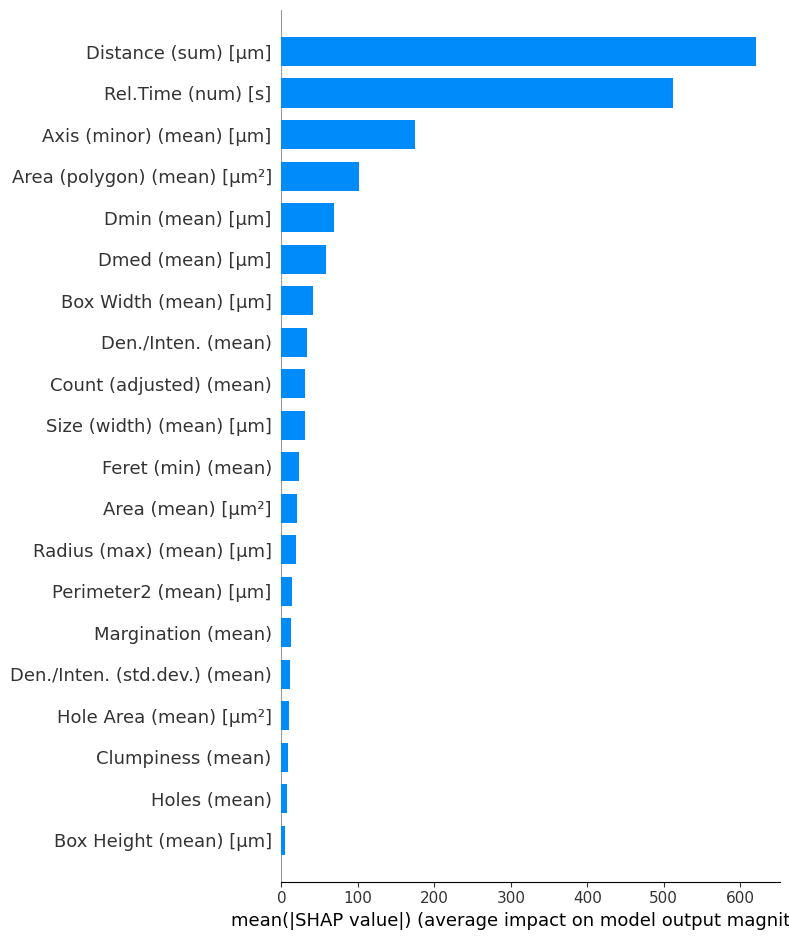

In [ ]:
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.tight_layout()

### PFE - GBR

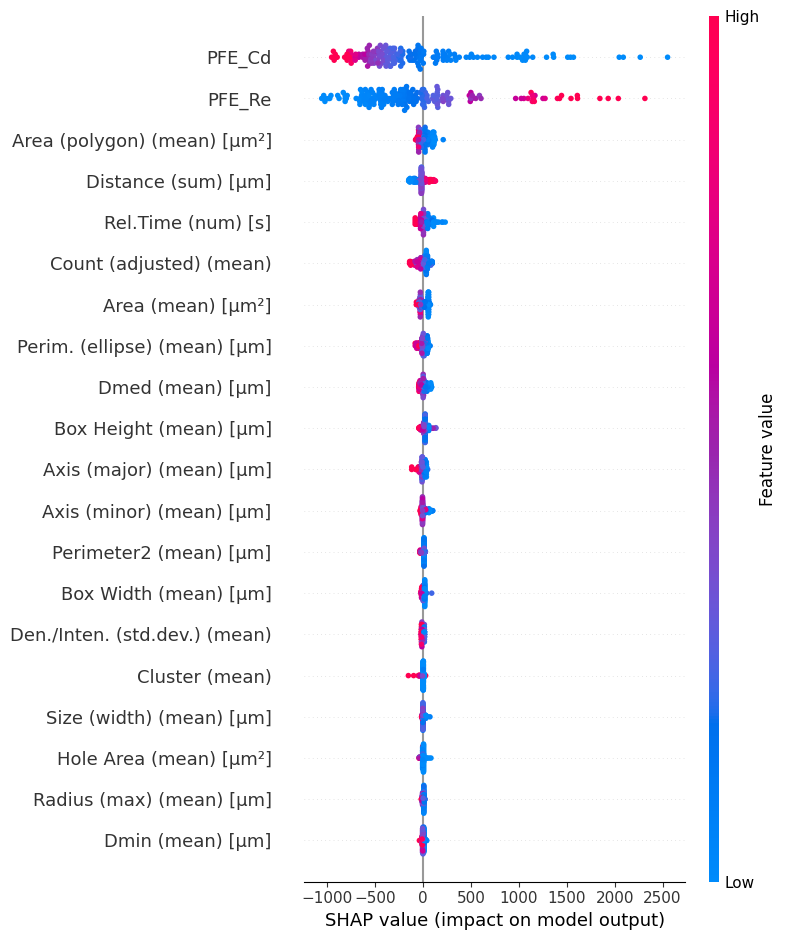

In [ ]:
# PFE - GBR
explainer = shap.Explainer(pfe_gbr_model)
shap_values_pfe = explainer(X_test_pfe)

shap.summary_plot(shap_values_pfe, X_test_pfe)


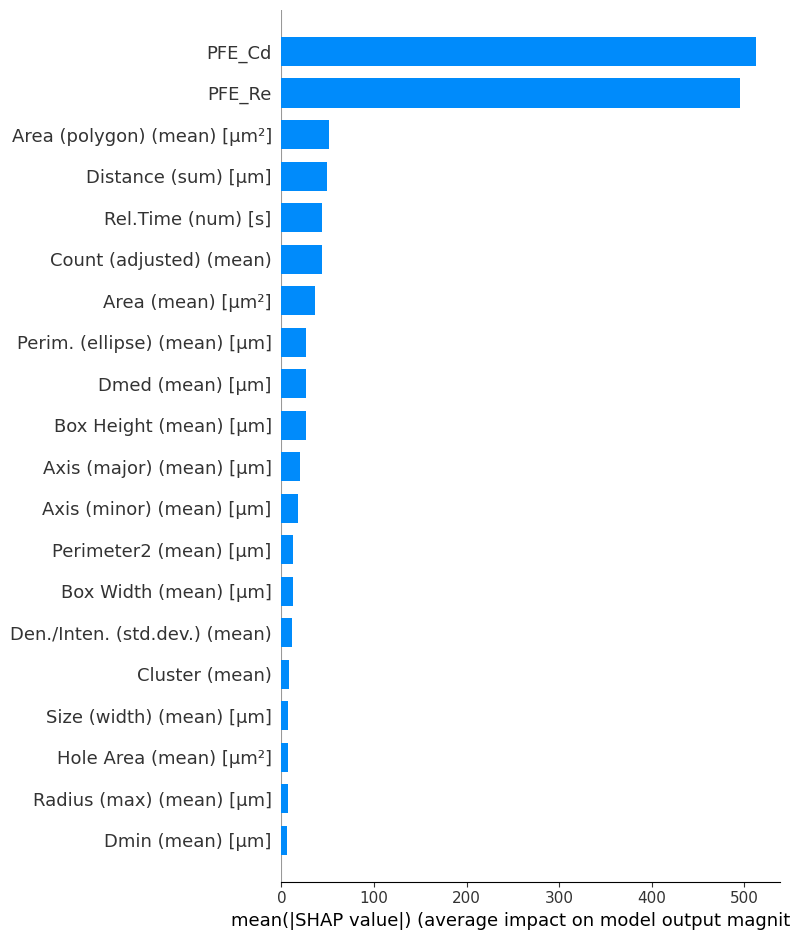

In [ ]:
shap.summary_plot(shap_values_pfe, X_test_pfe, plot_type="bar", show=False)
plt.tight_layout()

## debug

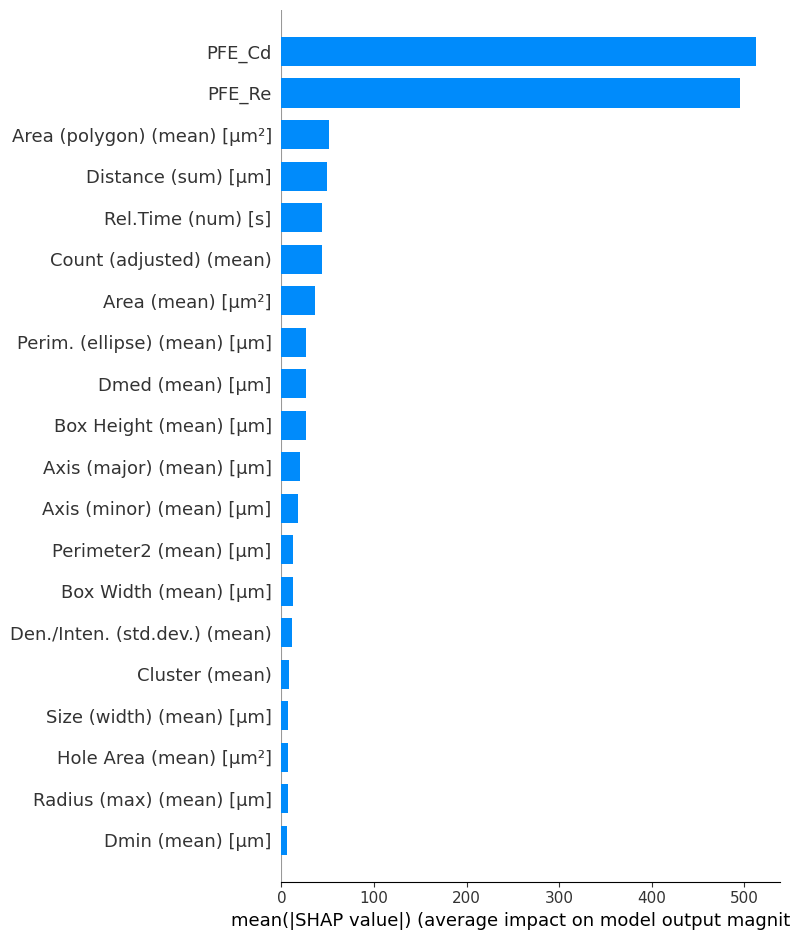

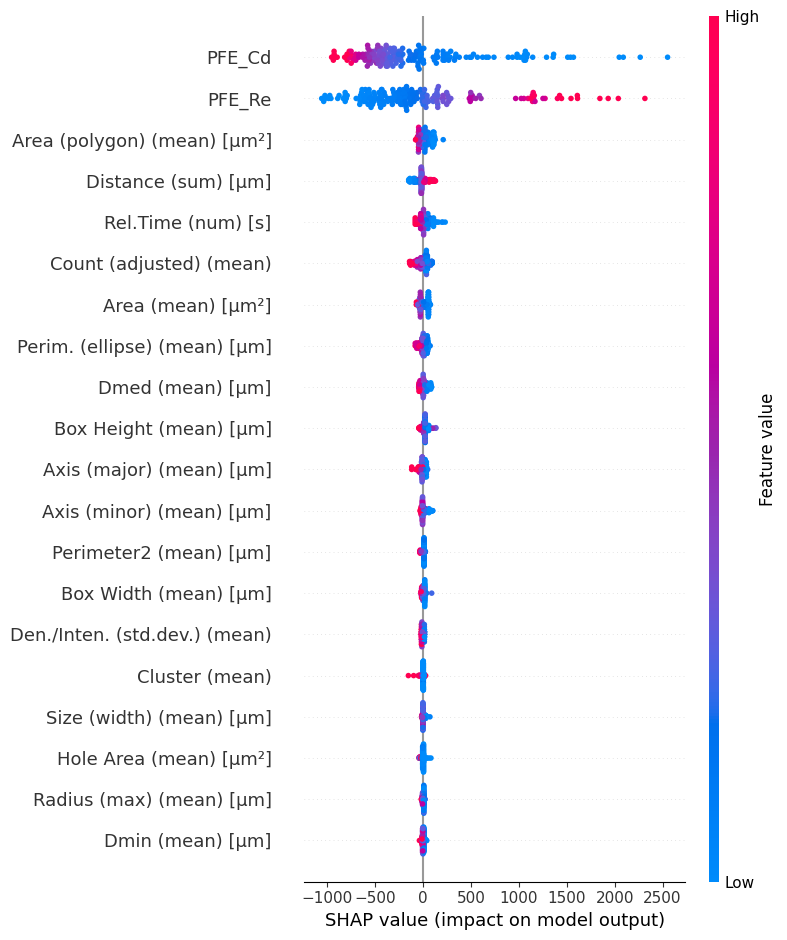

In [35]:
# 1) Carregar dados

file_path = './content/dados_jamovi.xlsx'  # Upload your dataset to Colab
df = pd.read_excel(file_path)


# 2) Definir alvo (velocidade medida)
target_col = "Velocity (mean) [µm/s]"
if target_col not in df.columns:
    raise ValueError(f"Coluna alvo não encontrada: {target_col}")

# 3) Construir features PFE (conforme manuscrito)
# Constantes (Seção 3.4.3 do artigo)
rho_f = 1000.0     # kg/m^3
mu = 0.001         # Pa*s

# Variáveis necessárias do dataset
area_um2 = df["Area (mean) [µm²]"]                 # área projetada
r_um = df["Radius (max) (mean) [µm]"]              # raio máximo
v_ums = df[target_col]                             # velocidade medida (µm/s)

# Conversões para SI
A = area_um2 * 1e-12       # µm² -> m²
r = r_um * 1e-6            # µm -> m
v = v_ums * 1e-6           # µm/s -> m/s

# Diâmetro equivalente por área projetada: d = 2*sqrt(A/pi)
d = 2.0 * np.sqrt(A / np.pi)

# Features físicas
Re = (rho_f * v * d) / mu
# evitar divisão por zero
Re = Re.replace([np.inf, -np.inf], np.nan)
Re = Re.where(Re > 0, np.nan)

Cd = 24.0 / Re
Fd = 0.5 * rho_f * Cd * A * (v ** 2)
r2 = r ** 2

# Inserir no dataframe (em unidades SI)
df["PFE_Re"] = Re
df["PFE_Cd"] = Cd
df["PFE_Fd"] = Fd
df["PFE_r2"] = r2

# 4) Seleção de features (usa todas exceto alvo; remove colunas não numéricas)
X_ = df.drop(columns=[target_col]).select_dtypes(include=[np.number]).copy()
y_ = df[target_col].copy()

# 5) Tratar NaNs gerados no PFE (por Re=0 etc.)
mask = X_.notna().all(axis=1) & y_.notna()
X_ = X_.loc[mask]
y_ = y_.loc[mask]

# 6) Split (80/20, seed 42)
X_train_, X_test_, y_train_, y_test_ = train_test_split(
    X_, y_, test_size=0.2, random_state=42
)

# 7) Modelo GBR com hiperparâmetros do manuscrito
model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model.fit(X_train_, y_train_)

# 8) Métricas (apenas conferência)
# y_pred = model.predict(X_test)
# mae = mean_absolute_error(y_test, y_pred)
# rmse = np.sqrt(mean_squared_error(y_test, y_pred))
# r2_sc = r2_score(y_test, y_pred)

# print(f"MAE:  {mae:.2f} µm/s")
# print(f"RMSE: {rmse:.2f} µm/s")
# print(f"R²:   {r2_sc:.3f}")

# 9) SHAP (TreeExplainer)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_)

# 10) Gráfico de importância (bar) e summary (beeswarm)
shap.summary_plot(shap_values, X_test_, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values, X_test_, show=False)
plt.tight_layout()
plt.show()

In [39]:
model

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft

In [40]:
pfe_gbr_model

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft

In [ ]:
model.get_params() == pfe_gbr_model.get_params()


True

In [42]:

len(model.estimators_) == len(pfe_gbr_model.estimators_)


True

In [38]:
X_test_pfe

,Dmax (mean) [µm],Dmed (mean) [µm],Dmin (mean) [µm],Area (mean) [µm²],Distance (sum) [µm],Rel.Time (num) [s],Area (polygon) (mean) [µm²],Area/Box (mean) [µm²],Axis (major) (mean) [µm],Axis (minor) (mean) [µm],...,Perimeter3 (mean) [µm],Radius (max) (mean) [µm],Radius (min) (mean) [µm],Roundness (mean),Size (length) (mean) [µm],Size (width) (mean) [µm],PFE_Re,PFE_Cd,PFE_Fd,PFE_r2
44,3444.190541,2277.320811,1125.498378,4.138137e+06,5750.27,37,3931818.18,0.51,3476.62,1600.56,...,10282.45,1841.48,457.98,2.14,3479.40,1811.72,3.666430,6.545877,3.455529e-08,3.391049e-06
839,3264.133333,2455.050833,1511.090625,4.920702e+06,14842.03,48,4716784.23,0.60,3356.21,1901.52,...,9284.25,1689.08,705.04,1.46,3269.04,2040.94,7.904311,3.036318,7.449638e-08,2.852991e-06
720,3259.284444,2263.453056,1591.890833,4.428158e+06,11626.41,36,4206048.53,0.47,3273.00,1887.70,...,11075.20,2016.91,653.87,2.35,3452.42,2214.11,7.461232,3.216627,7.032045e-08,4.067926e-06
660,6518.812727,3945.879091,1748.776818,1.418670e+07,9666.19,22,13859850.14,0.54,6256.70,3117.64,...,22755.11,3317.88,530.06,2.98,6412.89,3786.57,17.861717,1.343656,1.683427e-07,1.100833e-05
911,3136.153200,2408.649600,1890.947000,4.812445e+06,14073.32,50,4617799.53,0.63,2953.81,2111.67,...,8880.15,1652.12,837.00,1.36,2990.50,2219.97,7.109490,3.375770,6.700536e-08,2.729500e-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118,2196.584444,1691.822000,1178.224222,2.339429e+06,6062.59,45,2190514.67,0.57,2072.34,1515.51,...,7146.17,1182.32,516.11,1.86,2212.74,1722.92,2.378022,10.092421,2.241233e-08,1.397881e-06
388,2399.513291,1656.218734,886.718481,2.150727e+06,8067.68,79,1982261.81,0.55,2414.12,1222.72,...,8303.01,1323.37,312.05,2.79,2482.32,1474.79,1.711598,14.021985,1.613143e-08,1.751308e-06
494,1862.538471,1496.201882,1154.030235,1.799565e+06,17945.27,85,1685307.91,0.70,1791.94,1288.10,...,5184.63,956.03,531.13,1.27,1892.98,1335.07,3.158569,7.598378,2.976881e-08,9.139934e-07
29,1923.386596,1324.641915,1014.149362,1.405056e+06,6853.06,47,1298697.04,0.63,1789.62,1021.89,...,4969.56,1027.15,464.43,1.51,1963.62,1099.78,1.992639,12.044330,1.878018e-08,1.055037e-06


In [ ]:
X_test_pfe.describe()

,Dmax (mean) [µm],Dmed (mean) [µm],Dmin (mean) [µm],Area (mean) [µm²],Distance (sum) [µm],Rel.Time (num) [s],Area (polygon) (mean) [µm²],Area/Box (mean) [µm²],Axis (major) (mean) [µm],Axis (minor) (mean) [µm],...,Perimeter3 (mean) [µm],Radius (max) (mean) [µm],Radius (min) (mean) [µm],Roundness (mean),Size (length) (mean) [µm],Size (width) (mean) [µm],PFE_Re,PFE_Cd,PFE_Fd,PFE_r2
count,177.000000,177.000000,177.000000,1.770000e+02,177.000000,177.000000,1.770000e+02,177.000000,177.000000,177.000000,...,177.000000,177.000000,177.000000,177.000000,177.000000,177.000000,177.000000,177.000000,1.770000e+02,1.770000e+02
mean,2077.328924,1503.836775,983.968805,2.415567e+06,7642.796441,42.468927,2.302443e+06,0.600565,2057.305141,1251.657853,...,6659.149096,1150.686554,383.613503,1.934972,2107.394181,1399.887571,3.639064,15.643654,3.429737e-08,1.944761e-06
std,1368.218840,788.354341,453.729632,3.335880e+06,5368.515320,28.507981,3.386737e+06,0.084260,1334.199548,634.812400,...,5295.397486,790.068668,192.324735,0.909752,1382.920504,769.640039,4.356949,15.967160,4.106328e-08,4.283815e-06
min,621.754000,514.532000,180.057143,1.849864e+05,181.130000,5.000000,1.074070e+05,0.260000,616.220000,142.960000,...,1683.050000,345.820000,30.450000,1.110000,637.450000,155.210000,0.232989,0.742155,2.195866e-09,1.195915e-07
25%,1246.211200,987.686786,687.241538,8.393786e+05,3116.190000,19.000000,7.607181e+05,0.550000,1223.230000,853.850000,...,3717.460000,655.300000,245.190000,1.450000,1236.590000,945.670000,1.262571,6.091022,1.189946e-08,4.294181e-07
50%,1752.845909,1380.161571,905.540625,1.474253e+06,6849.280000,42.000000,1.372129e+06,0.610000,1784.720000,1128.010000,...,5291.380000,945.780000,360.350000,1.710000,1773.370000,1273.850000,2.036902,11.782598,1.919735e-08,8.944998e-07
75%,2348.077200,1784.359167,1178.224222,2.462312e+06,11038.770000,59.000000,2.301000e+06,0.660000,2414.120000,1512.890000,...,7590.920000,1342.660000,476.520000,2.170000,2482.320000,1673.350000,3.940225,19.008826,3.713575e-08,1.802736e-06
max,10541.508571,5586.506000,2919.312000,2.861185e+07,18250.980000,169.000000,2.975403e+07,0.760000,9771.780000,4480.460000,...,47226.890000,6963.890000,1134.190000,9.100000,11033.960000,5582.330000,32.338254,103.009303,3.047809e-07,4.849576e-05


In [ ]:
X_test_.describe()

,Dmax (mean) [µm],Dmed (mean) [µm],Dmin (mean) [µm],Area (mean) [µm²],Distance (sum) [µm],Rel.Time (num) [s],Area (polygon) (mean) [µm²],Area/Box (mean) [µm²],Axis (major) (mean) [µm],Axis (minor) (mean) [µm],...,Perimeter3 (mean) [µm],Radius (max) (mean) [µm],Radius (min) (mean) [µm],Roundness (mean),Size (length) (mean) [µm],Size (width) (mean) [µm],PFE_Re,PFE_Cd,PFE_Fd,PFE_r2
count,177.000000,177.000000,177.000000,1.770000e+02,177.000000,177.000000,1.770000e+02,177.000000,177.000000,177.000000,...,177.000000,177.000000,177.000000,177.000000,177.000000,177.000000,177.000000,177.000000,1.770000e+02,1.770000e+02
mean,2077.328924,1503.836775,983.968805,2.415567e+06,7642.796441,42.468927,2.302443e+06,0.600565,2057.305141,1251.657853,...,6659.149096,1150.686554,383.613503,1.934972,2107.394181,1399.887571,3.639064,15.643654,3.429737e-08,1.944761e-06
std,1368.218840,788.354341,453.729632,3.335880e+06,5368.515320,28.507981,3.386737e+06,0.084260,1334.199548,634.812400,...,5295.397486,790.068668,192.324735,0.909752,1382.920504,769.640039,4.356949,15.967160,4.106328e-08,4.283815e-06
min,621.754000,514.532000,180.057143,1.849864e+05,181.130000,5.000000,1.074070e+05,0.260000,616.220000,142.960000,...,1683.050000,345.820000,30.450000,1.110000,637.450000,155.210000,0.232989,0.742155,2.195866e-09,1.195915e-07
25%,1246.211200,987.686786,687.241538,8.393786e+05,3116.190000,19.000000,7.607181e+05,0.550000,1223.230000,853.850000,...,3717.460000,655.300000,245.190000,1.450000,1236.590000,945.670000,1.262571,6.091022,1.189946e-08,4.294181e-07
50%,1752.845909,1380.161571,905.540625,1.474253e+06,6849.280000,42.000000,1.372129e+06,0.610000,1784.720000,1128.010000,...,5291.380000,945.780000,360.350000,1.710000,1773.370000,1273.850000,2.036902,11.782598,1.919735e-08,8.944998e-07
75%,2348.077200,1784.359167,1178.224222,2.462312e+06,11038.770000,59.000000,2.301000e+06,0.660000,2414.120000,1512.890000,...,7590.920000,1342.660000,476.520000,2.170000,2482.320000,1673.350000,3.940225,19.008826,3.713575e-08,1.802736e-06
max,10541.508571,5586.506000,2919.312000,2.861185e+07,18250.980000,169.000000,2.975403e+07,0.760000,9771.780000,4480.460000,...,47226.890000,6963.890000,1134.190000,9.100000,11033.960000,5582.330000,32.338254,103.009303,3.047809e-07,4.849576e-05


In [ ]:
(X_test_ - X_test_pfe).sum()

Dmax (mean) [µm]                 0.0
Dmed (mean) [µm]                 0.0
Dmin (mean) [µm]                 0.0
Area (mean) [µm²]                0.0
Distance (sum) [µm]              0.0
Rel.Time (num) [s]               0.0
Area (polygon) (mean) [µm²]      0.0
Area/Box (mean) [µm²]            0.0
Axis (major) (mean) [µm]         0.0
Axis (minor) (mean) [µm]         0.0
Box Height (mean) [µm]           0.0
Box Width (mean) [µm]            0.0
Box X/Y (mean) [µm]              0.0
Clumpiness (mean)                0.0
Cluster (mean)                   0.0
Count (adjusted) (mean)          0.0
Den./Inten. (std.dev.) (mean)    0.0
Den./Inten. (mean)               0.0
Feret (max) (mean)               0.0
Feret (mean) (mean)              0.0
Feret (min) (mean)               0.0
Fractal Dim. (mean)              0.0
Heterogeneity (mean)             0.0
Hole Area (mean) [µm²]           0.0
Hole Ratio (mean)                0.0
Holes (mean)                     0.0
Margination (mean)               0.0
P

# 6. Robustness Analysis - Noise Injection

def inject_noise(X, noise_level):
    noise = np.random.normal(0, noise_level, X.shape)
    return X + noise


In [ ]:
# noise_levels = [0.0, 0.01, 0.05, 0.1]
# results_noise = []

# for nl in noise_levels:
#     X_noisy = inject_noise(X_physics, nl)
#     res = evaluate_cv(gbr, X_noisy, y)
#     res["noise_level"] = nl
#     results_noise.append(res)

# df_noise = pd.DataFrame(results_noise)
# df_noise

## Performance Degradation Under Noise

plt.plot(df_noise["noise_level"], df_noise["RMSE_mean"], marker="o")
plt.xlabel("Noise Level")
plt.ylabel("RMSE")
plt.title("RMSE vs Noise Level")
plt.show()


# 7. Error Analysis by Morphological Class

In [ ]:
# classes = df.loc[X_test.index, "morphological_class"]

# error_by_class = (
#     pd.DataFrame({
#         "class": classes,
#         "abs_error": np.abs(residuals)
#     })
#     .groupby("class")
#     .mean()
# )

# error_by_class